# 3.1 Análisis Exploratorio de Datos (EDA)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

#Cargar el Dataset
df = pd.read_csv('data/retailmax.csv')

# 1. ¿Cuál es la distribución de edades de los clientes?

Objetivo: Comprender la distribución de las edades en el conjunto de datos.

Respuesta esperada: Un histograma de la columna Age.

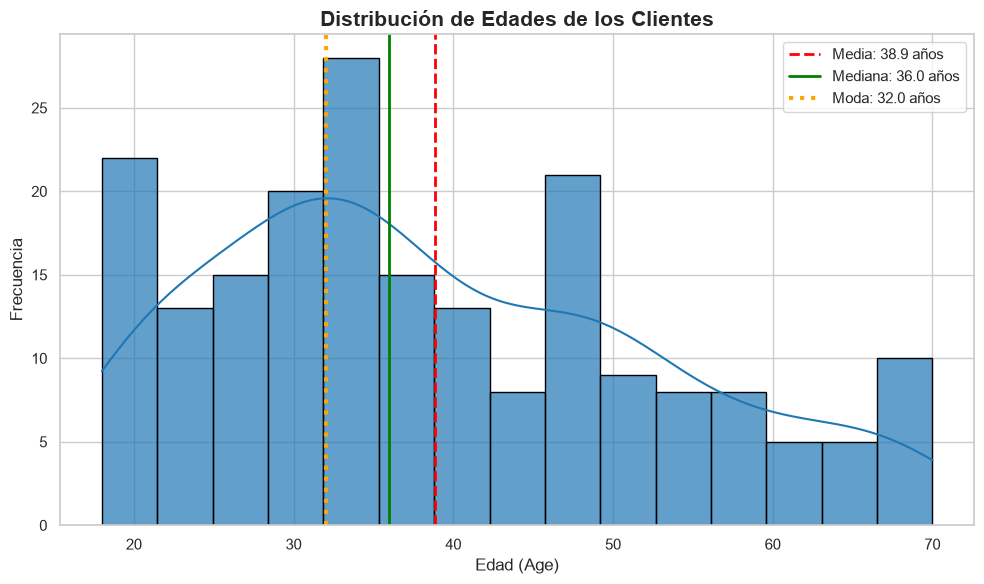

In [ ]:


# Configuración visual
sns.set_theme(style="whitegrid")

# Calcular estadísticas
media = df["Age"].mean()
mediana = df["Age"].median()
moda = df["Age"].mode()[0]

# Establecer tamaño de grafica
plt.figure(figsize=(10, 6))

# Histograma y curva de densidad
sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True,
    color="#1f77b4",
    edgecolor="black",
    alpha=0.7
)

# Línea de la media
plt.axvline(
    media,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media: {media:.1f} años"
)

# Línea de la mediana
plt.axvline(
    mediana,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Mediana: {mediana:.1f} años"
)

# Línea de la moda
plt.axvline(
    moda,
    color="orange",
    linestyle=":",
    linewidth=3,
    label=f"Moda: {moda:.1f} años"
)

# Título y etiquetas
plt.title("Distribución de Edades de los Clientes", fontsize=15, fontweight="bold")
plt.xlabel("Edad (Age)")
plt.ylabel("Frecuencia")

# Leyenda
plt.legend()

plt.tight_layout()
plt.show()

# Análisis de Resultados (1)

Al observar la distribución de edades de los clientes, se aprecia que la mayoría se concentra entre los 25 y 45 años. La distribución presenta una forma relativamente equilibrada, aunque con una ligera concentración alrededor de los 30 años.

La media y la mediana se encuentran muy cercanas, lo que indica que no existe un sesgo extremo hacia edades muy jóvenes o muy avanzadas. También se observa una presencia menor de clientes en el extremo de mayor edad.

En conclusión, la base de clientes está compuesta principalmente por adultos jóvenes (25 a 32 años) y de mediana edad (35 a 45 años). Este grupo representa el segmento predominante del negocio y puede ser un objetivo importante para estrategias de marketing y ventas.


# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

Objetivo: Comparar la distribución de ingresos anuales entre géneros.

Respuesta esperada: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

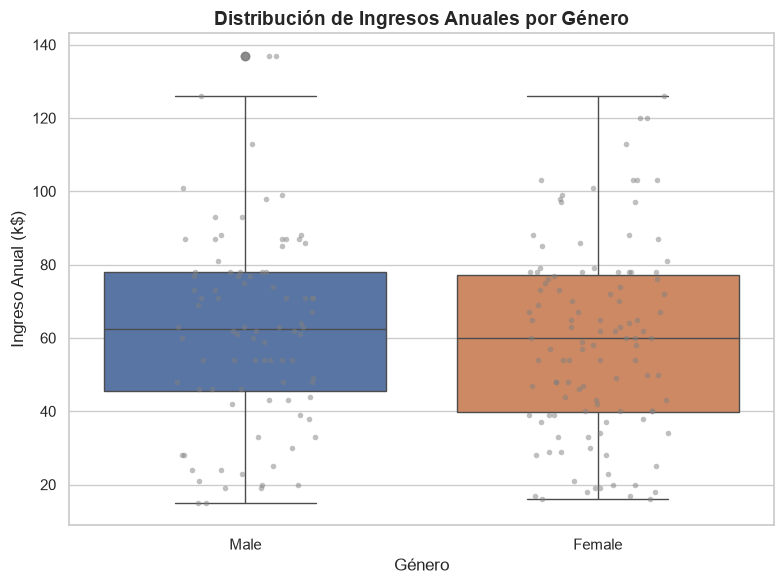

In [5]:
#Configuración visual
sns.set_theme(style="whitegrid")

#Establecer tamaño de grafica
plt.figure(figsize=(8, 6))

#Boxplot con colores diferentes y outliers grises
sns.boxplot(
    data=df,
    x="Gender",
    y="Annual Income (k$)",
    palette=["#4C72B0", "#DD8452"],  # Azul y naranja
    flierprops={
        "marker": "o",
        "markerfacecolor": "gray",
        "markeredgecolor": "gray",
        "markersize": 6,
        "alpha": 0.7
    }
)

# Puntos individuales grises
sns.stripplot(
    data=df,
    x="Gender",
    y="Annual Income (k$)",
    color="gray",
    alpha=0.5,
    jitter=0.20,
    size=4
)

#Titulo de la grafica
plt.title(
    "Distribución de Ingresos Anuales por Género",
    fontsize=14,
    fontweight="bold"
)
#Etiquetas de los ejes
plt.xlabel("Género")
plt.ylabel("Ingreso Anual (k$)")

plt.tight_layout()
plt.show()

# Análisis de Resultados (2)

Al comparar la distribución de los ingresos anuales entre ambos sexos, mediante el diagrama de cajas, se observa que ambos grupos presentan distribuciones muy similares.

Hombres:
  Promedio  62.23 k$
  Mediana   62.50 k$

Mujeres:
  Promedio  59.25 k$
  Mediana   60.00 k$

Las medianas se encuentran en valores cercanos y el rango intercuartílico muestra una dispersión comparable en ambos géneros (IQR hombres = 32.5 k$ , mujeres = 37.5 k$).

También se aprecia que existen algunos valores atípicos (outliers) tanto en hombres como en mujeres, lo que indica la presencia de clientes con ingresos significativamente superiores al promedio. Sin embargo, estos casos son poco frecuentes y no alteran la tendencia general de los datos.

En términos generales, no se observan diferencias significativas en los ingresos anuales entre hombres y mujeres dentro de este conjunto de datos. Esto sugiere que el género no parece ser un factor determinante en el nivel de ingresos de los clientes analizados.


# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

Objetivo: Analizar la relación entre la edad y la puntuación de gasto.

Respuesta esperada: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

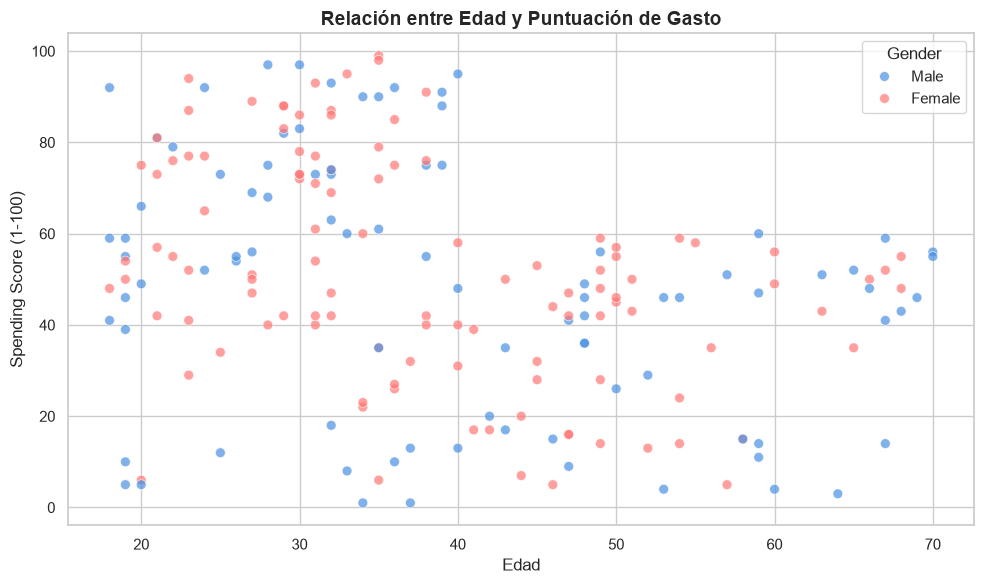

In [15]:
#Configuración visual
sns.set_theme(style="whitegrid")

#Establecer tamaño de grafica
plt.figure(figsize=(10, 6))

#Gráfico de dispersión
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue='Gender',
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    alpha=0.7,
    s=50
)

#Título
plt.title(
    "Relación entre Edad y Puntuación de Gasto",
    fontsize=14,
    fontweight="bold"
)

#Etiquetas de los ejes
plt.xlabel("Edad")
plt.ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

# Análisis de  Resultados (3)

Al analizar la relación entre la edad y la puntuación de gasto, se observa una relacion entre la edad y la puntuacion de gasto de los clientes.

Primero, hay una clara barrera alrededor de los 40 años. Prácticamente ningún cliente mayor de 40 años supera una puntuación de gasto de 60 puntos. La gran mayoría de los clientes de más de 40 años se concentra en un rango de puntuación moderado y bajo (entre 1 y 60 puntos), con una media que ronda los 32-34 puntos.

Segundo, los clientes de entre 18 y 40 años muestran una dispersión mucho mayor y son los únicos que alcanzan puntuaciones de gasto sobresalientes (entre 60 y 100 puntos). En este segmento joven, se aprecian claramente dos grupos bien diferenciados: uno de perfil muy ahorrador o moderado (puntuaciones bajas) y otro de perfil altamente consumidor (puntuaciones que van de 60 a 99 puntos).


En conclusión, la edad es un factor altamente segmentador en este conjunto de datos. Mientras que los clientes jóvenes (menos de 40 años) presentan un grupo con potencial de compra sumamente elevado, el segmento de mayor edad (mayores o iguales a 40 años) exhibe un comportamiento de gasto mucho más moderado y homogéneo, sin superar nunca la franja alta de puntuación.


# 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?

Objetivo: Identificar si existe una relación lineal entre el ingreso y el gasto.

Respuesta esperada: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

Coeficiente de correlación: 0.010


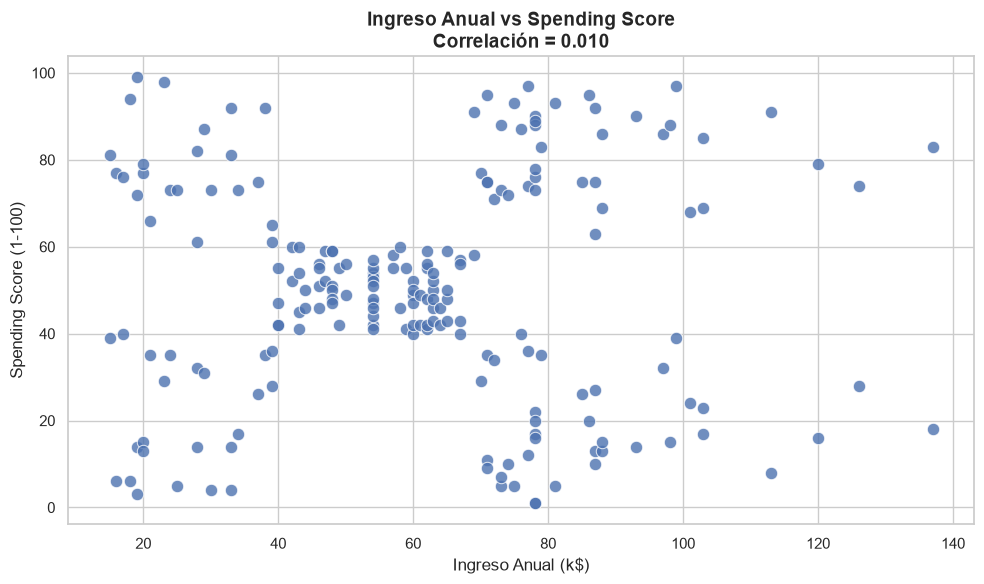

In [ ]:
#Calcular correlación
correlacion = df["Annual Income (k$)"].corr(df["Spending Score (1-100)"])

print(f"Coeficiente de correlación: {correlacion:.3f}")

#Gráfica de dispersión
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    alpha=0.8,
    s=80
)

#Título y etiquetas
plt.title(
    f"Ingreso Anual vs Spending Score\nCorrelación = {correlacion:.3f}",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Ingreso Anual (k$)")
plt.ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

# Análisis de Resultados (4)

El coeficiente de correlación entre el ingreso anual y la puntuación de gasto es de aproximadamente 0.01 , un valor positivo pero muy cercano a cero. Esto indica que prácticamente no existe una relación lineal entre ambas variables, por lo que el nivel de ingresos no permite predecir de forma fiable el comportamiento de gasto de los clientes.

Al observar la gráfica de dispersión, los puntos se encuentran ampliamente distribuidos a lo largo de todo el rango de ingresos, sin formar una tendencia ascendente o descendente clara, pero sí observandose una fuerte concentracion los clientes de ingresos medios.

 -Los clientes de ingresos bajos (entre 15 y 40 k$) presentan una clara segmentación; puntuaciones de gasto muy reducidas y otroso con valores cercanos a 100 puntos.

 -Los clientes de ingresos medios (entre 40 y 70 k$) forman un grupo muy homogéneo alrededor de un Spending Score de 50.

 -Los clientes de ingresos altos (entre 70 y 140 k$) se dividen claramente entre perfiles de bajo consumo como perfiles de gasto intensivo.


En conclusion, el ingreso anual no parece ser un factor determinante para explicar la puntuación de gasto de los clientes en este conjunto de datos(estas variables son casi independientes entre sí). Los resultados sugieren que otras características (edad, preferencias de consumo o factores de comportamiento individuales) podrían tener una influencia mucho mayor sobre la puntuación de gasto. Así, para comprender mejor los patrones de consumo de los clientes, sería recomendable complementar este análisis con otras variables y técnicas de segmentación.


# 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?

Objetivo: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.

Respuesta esperada: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

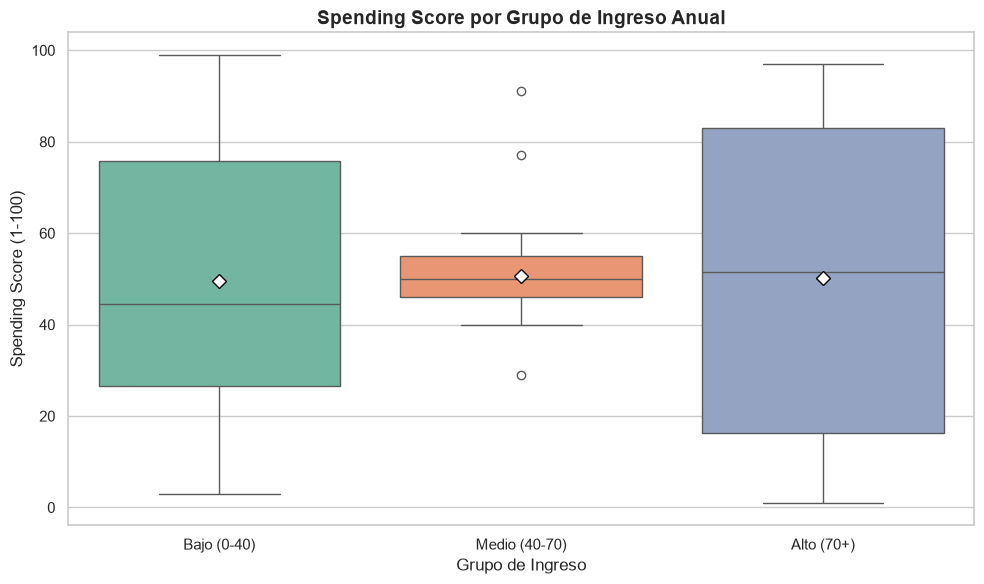

In [ ]:
#Crear grupos de ingresos
df["Income_Group"] = pd.cut(
    df["Annual Income (k$)"],
    bins=[0, 40, 70, 140],
    labels=["Bajo (0-40)", "Medio (40-70)", "Alto (70+)"]
)

#Gráfica
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Income_Group",
    y="Spending Score (1-100)",
    palette="Set2",
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

#Título y etiquetas
plt.title(
    "Spending Score por Grupo de Ingreso Anual",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Grupo de Ingreso")
plt.ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

# Análisis de Resultados (5)

La distribución de la puntuación de gasto varía considerablemente según el grupo de ingresos anuales:

  -Los clientes con ingresos bajos (0-40 k$) y altos (70+ k$) presentan una gran dispersión en sus puntuaciones de gasto, abarcando prácticamente todo el rango posible, desde valores muy bajos hasta valores cercanos a 100 puntos.

 -Los clientes con ingresos medios (40-70 k$) muestran un comportamiento mucho más homogéneo. La mayoría de sus puntuaciones se concentra alrededor de los 50 puntos, con una variabilidad considerablemente menor que la observada en los otros grupos.

Las medianas de los tres grupos son similares, situándose cerca de los 50 puntos, lo que indica que el nivel de ingreso no altera significativamente la puntuación central de gasto. Sin embargo, sí influye en la dispersión del comportamiento de los clientes.

En conclusión, los grupos de ingresos bajos y altos contienen perfiles de consumo muy diversos, mientras que los clientes de ingresos medios presentan hábitos de gasto más consistentes y moderados. Esto refuerza la idea de que el ingreso anual, por sí solo, no explica completamente el comportamiento de gasto de los clientes.

# 6. ¿Cuál es la proporción de clientes por género?

Objetivo: Determinar el balance de género en el conjunto de datos.

Respuesta esperada: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

Gender
Female    112
Male       88
Name: count, dtype: int64
Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


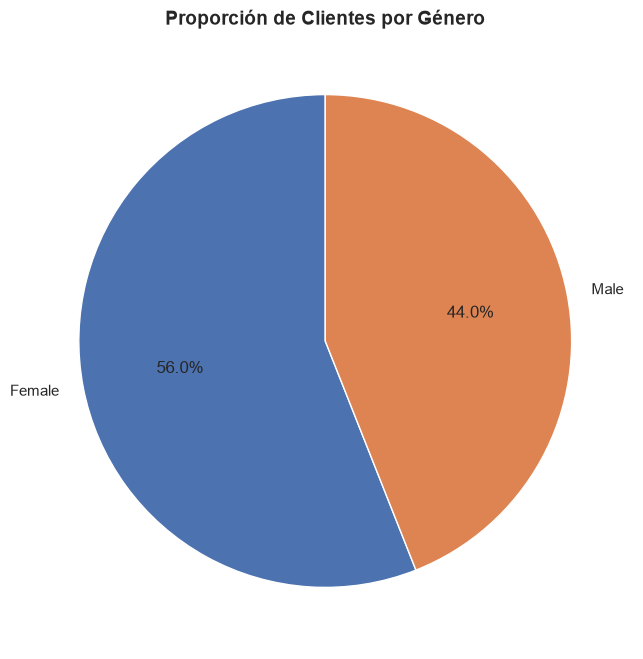

In [21]:
#calcular los porcentajes exactos
print(df["Gender"].value_counts())
print(df["Gender"].value_counts(normalize=True) * 100)


#Conteo por género
gender_counts = df["Gender"].value_counts()

#Gráfica de pastel
plt.figure(figsize=(8, 8))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

#titulo de la grafica
plt.title(
    "Proporción de Clientes por Género",
    fontsize=14,
    fontweight="bold"
)

plt.show()



# Análisis de Resultados (6)

La distribución de clientes por género muestra una predominancia del género femenino. Las mujeres (112) representan aproximadamente el 56% de los clientes, mientras que los hombres (88) constituyen cerca del 44%.

Aunque la diferencia no es extremadamente grande, el conjunto de datos contiene una mayor cantidad de mujeres, lo que podría influir en algunos análisis posteriores relacionados con hábitos de compra y de segmentación de clientes.


En conclusion, el conjunto de datos presenta una distribución relativamente equilibrada entre ambos géneros, aunque con una mayor representación femenina. Esto sugiere que las estrategias de análisis y segmentación deben considerar a ambos grupos, prestando especial atención al segmento femenino debido a su mayor participación en la muestra.


# 7. ¿Qué grupos de edad gastan más en promedio?

Objetivo: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio. 

Respuesta esperada: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

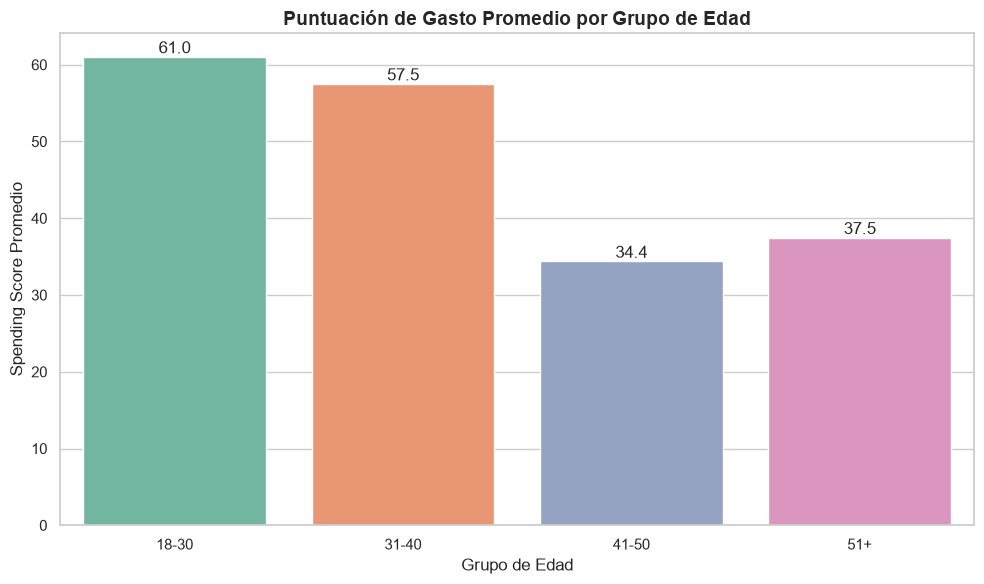

In [ ]:
#Promedio de Spending Score por grupo de edad
promedio_gasto = (
    df.groupby("Age_Group", observed=False)["Spending Score (1-100)"]
      .mean()
      .reset_index()
)

#Gráfica de barras
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=promedio_gasto,
    x="Age_Group",
    y="Spending Score (1-100)",
    palette="Set2"
)

#Mostrar valor sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

#Titulo y etiquetas
plt.title(
    "Puntuación de Gasto Promedio por Grupo de Edad",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Grupo de Edad")
plt.ylabel("Spending Score Promedio")


plt.tight_layout()
plt.show()

# Analisis de Resultados (7)

La gráfica muestra diferencias claras en la puntuación de gasto promedio entre los distintos grupos de edad:

 -El grupo de 18 a 30 años presenta el mayor Spending Score promedio, con un valor de 61.0 puntos.

 -El grupo de 31 a 40 años, sigue de cerca con un promedio de 57.5 puntos.

 -El grupo de 41 a 50 años registra el promedio más bajo, con 34.4 puntos, lo que sugiere hábitos de consumo más moderados.
 
 -El grupo de 51 años o más presenta un promedio ligeramente superior, de 37.5 puntos, aunque sigue siendo considerablemente menor que el de los grupos más jóvenes.

La diferencia entre el grupo con mayor gasto promedio (18-30 años) y el de menor gasto promedio (41-50 años) es de aproximadamente 26.6 puntos, una brecha importante que evidencia el impacto de la edad en el comportamiento de compra.

En conclusión, esto indica que los clientes menores a 40 años son los que, en promedio, muestran una mayor propensión al gasto, especialmente el grupo de 18 a 30 años. En contraste, los clientes entre 41 y 50 años presentan los niveles de gasto más bajos. Estos resultados sugieren que la edad es una variable relevante para comprender y segmentar el comportamiento de consumo de los clientes.


# 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?

Objetivo: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.

Respuesta esperada: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

Correlación: -0.012


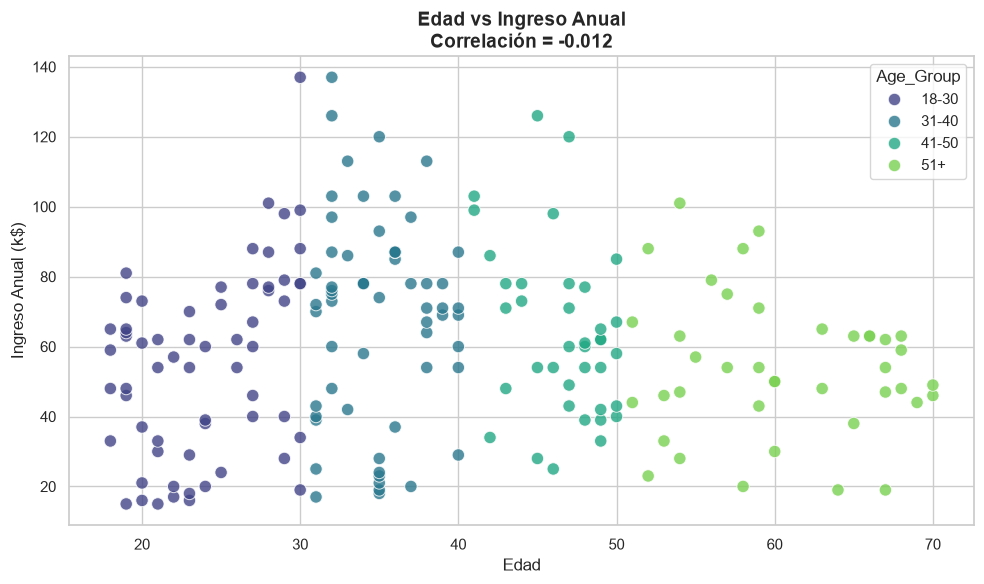

In [23]:

# Calcular correlación
correlacion = df["Age"].corr(df["Annual Income (k$)"])

print(f"Correlación: {correlacion:.3f}")

# Gráfica de dispersión
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Annual Income (k$)",
    hue="Age_Group",
    palette="viridis",
    alpha=0.8,
    s=80
)

plt.title(
    f"Edad vs Ingreso Anual\nCorrelación = {correlacion:.3f}",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Edad")
plt.ylabel("Ingreso Anual (k$)")

plt.tight_layout()
plt.show()

# Análisis de los Resultados (8)

La gráfica de dispersión muestra una correlación de -0.012 entre la edad y el ingreso anual, un valor extremadamente cercano a cero. Esto indica que no existe una relación lineal significativa entre ambas variables.

Visualmente, los puntos se encuentran distribuidos a lo largo de prácticamente todos los rangos de ingreso para cada grupo de edad. Se observan clientes jóvenes con ingresos bajos, medios y altos, así como clientes mayores con una amplia variedad de niveles de ingreso.

Sin embargo, sí aparecen algunos patrones interesantes:

 -Los clientes de 18 a 30 años presentan una gran diversidad de ingresos, aunque predominan los valores entre 20 y 80 k$.

 -El grupo de 31 a 40 años concentra varios de los ingresos más altos del conjunto de datos, incluyendo algunos superiores a 120 k$.

 -Los clientes de 41 a 50 años mantienen una distribución amplia de ingresos, similar a la de los grupos más jóvenes.

 -Los clientes de 51 años o más muestran una menor presencia de ingresos extremadamente altos y una mayor concentración entre 40 y 70 k$.

A pesar de estas diferencias visuales, no se observa una tendencia ascendente o descendente clara conforme aumenta la edad. Existen clientes con ingresos similares en prácticamente todos los grupos etarios.


En conclusion, la edad no parece ser un buen predictor del ingreso anual en este conjunto de datos. El coeficiente de correlación cercano a cero y la amplia dispersión de los puntos sugieren que ambas variables son prácticamente independientes. Aunque algunos grupos de edad presentan concentraciones particulares de ingresos, no existe una tendencia general que indique que los ingresos aumentan o disminuyen sistemáticamente con la edad.


# 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?

Objetivo: Entender cómo se distribuyen estas dos variables en conjunto.

Respuesta esperada: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

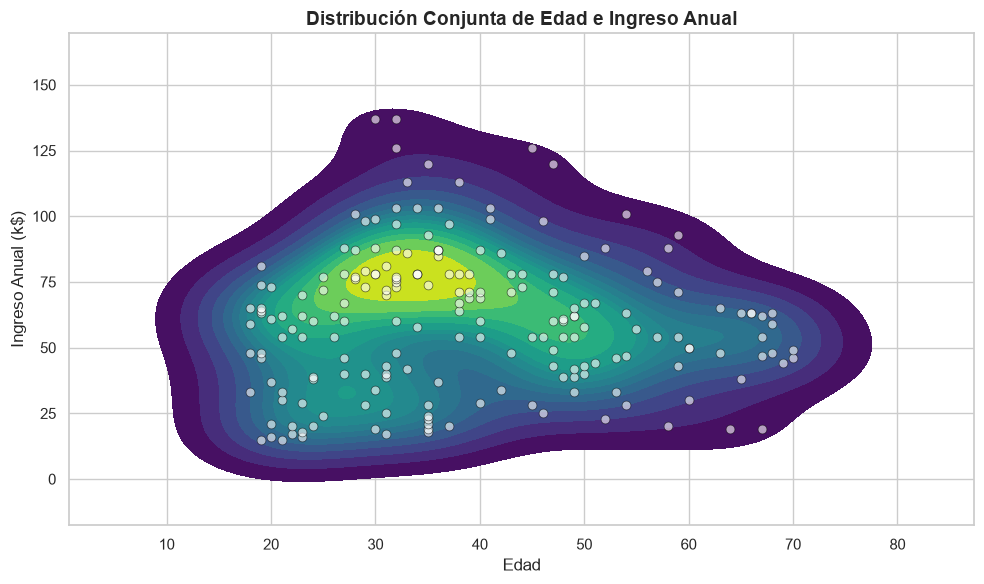

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x="Age",
    y="Annual Income (k$)",
    fill=True,
    cmap="viridis",
    levels=15,
    thresh=0.05
)

sns.scatterplot(
    data=df,
    x="Age",
    y="Annual Income (k$)",
    color="white",
    edgecolor="black",
    alpha=0.6,
    s=40
)

plt.title(
    "Distribución Conjunta de Edad e Ingreso Anual",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Edad")
plt.ylabel("Ingreso Anual (k$)")

plt.tight_layout()
plt.show()

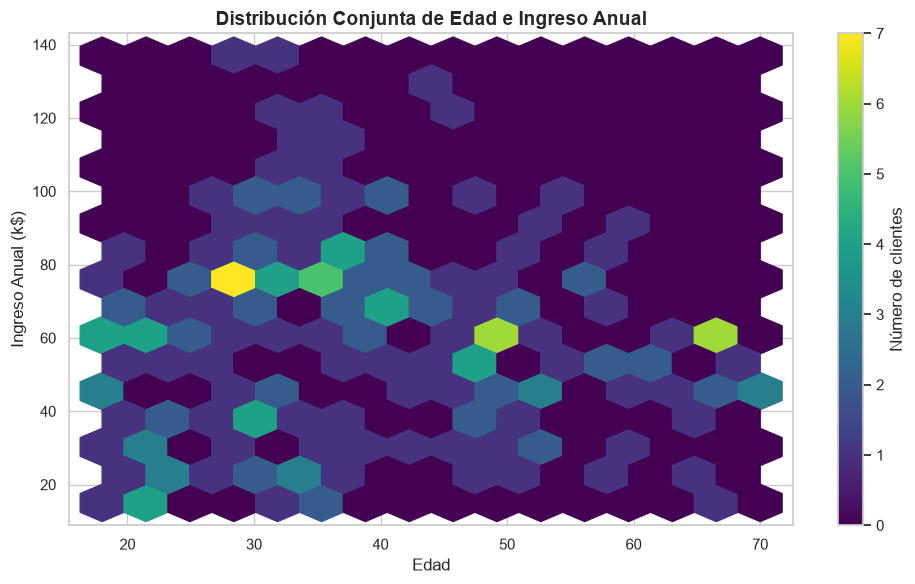

In [26]:
plt.figure(figsize=(10, 6))

plt.hexbin(
    df["Age"],
    df["Annual Income (k$)"],
    gridsize=15,
    cmap="viridis"
)

plt.colorbar(label="Número de clientes")

plt.title(
    "Distribución Conjunta de Edad e Ingreso Anual",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Edad")
plt.ylabel("Ingreso Anual (k$)")

plt.tight_layout()
plt.show()

# Análisis de los Resultados (9)

Las gráficas de distribución conjunta muestran cómo se concentran los clientes según su edad e ingreso anual.
 -La zona de mayor densidad se encuentra aproximadamente entre los 30 y 40 años de edad y entre 60 y 80 k$ de ingreso anual. 

 -La segunda zona de concentración se observa entre clientes de 40 y 55 años con ingresos entre 40-65 k$. 
 
 -Las regiones correspondientes a ingresos muy altos (superiores a 100 k$) o edades extremas presentan una densidad mucho menor, lo que indica que estos perfiles son menos frecuentes en el conjunto de datos.

La distribución de densidad tiene una forma relativamente horizontal, extendiéndose a través de distintas edades para niveles de ingreso similares. Esto coincide con el coeficiente de correlación previamente calculado (-0.012), sugiriendo que no existe una relación lineal importante entre la edad y el ingreso anual.



En conclusion, la mayor parte de los clientes pertenece al segmento demográfico en edades de 30 a 40 años con ingresos medios (60 y 80 k$). Esto indica que aunque existen clientes jóvenes y mayores con ingresos variados, no se aprecia una tendencia clara que indique que los ingresos aumenten o disminuyan con la edad. En consecuencia, la edad y el ingreso anual parecen comportarse como variables prácticamente independientes dentro de este conjunto de datos. 


# 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?

Objetivo: Analizar la relación entre la puntuación de gasto y el género.

Respuesta esperada: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

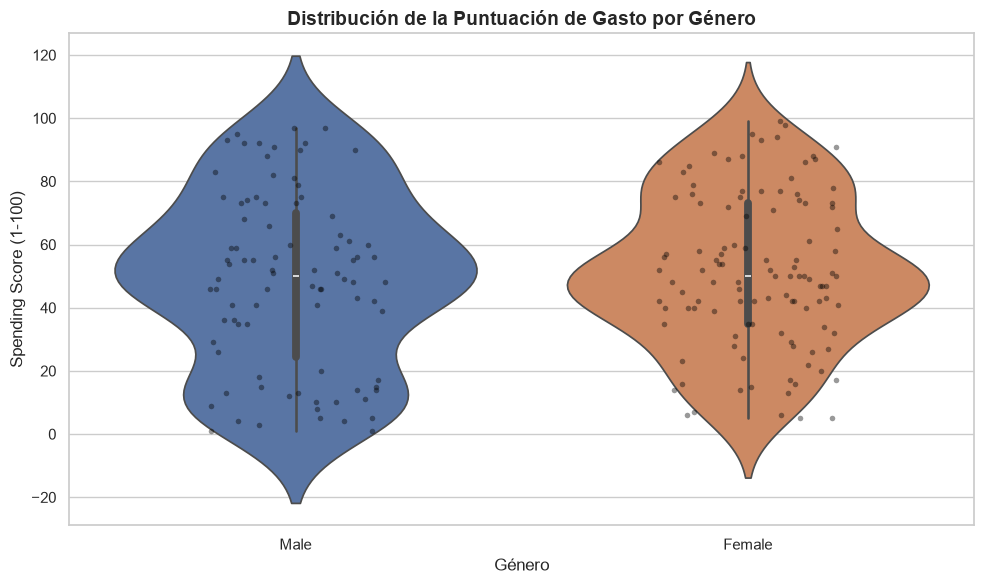

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)",
    palette=["#4C72B0", "#DD8452"],
    inner="box"
)

sns.stripplot(
    data=df,
    x="Gender",
    y="Spending Score (1-100)",
    color="black",
    alpha=0.4,
    jitter=0.2,
    size=4
)

plt.title(
    "Distribución de la Puntuación de Gasto por Género",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Género")
plt.ylabel("Spending Score (1-100)")

plt.tight_layout()
plt.show()

# Análisis de los Resultados (10)

La gráfica de violín muestra que hombres y mujeres presentan distribuciones de Spending Score muy similares. En ambos grupos, la mediana se sitúa aproximadamente alrededor de los 50 puntos, lo que indica que el nivel típico de gasto es prácticamente el mismo para ambos géneros.

La dispersión también es comparable. Tanto hombres como mujeres presentan puntuaciones que abarcan casi todo el rango posible, desde valores muy bajos cercanos a 0 hasta valores próximos a 100. Esto sugiere una gran diversidad de comportamientos de consumo dentro de cada género.

La forma de los violines revela además una concentración importante de clientes alrededor de los valores medios (40-60 puntos), acompañada por grupos de clientes con puntuaciones muy bajas y muy altas. Este patrón aparece en ambos géneros, aunque las mujeres muestran una ligera mayor presencia en las puntuaciones más altas (70-90), mientras que los hombres presentan una concentración algo más marcada alrededor de los valores medios.

Sin embargo, estas diferencias visuales son pequeñas en comparación con la similitud general de las distribuciones.

En conclusion, no se observan diferencias significativas en la puntuación de gasto entre hombres y mujeres. Ambos géneros presentan medianas muy parecidas, niveles de dispersión similares y una distribución general casi idéntica. Esto sugiere que el género, por sí solo, no parece ser un factor determinante para explicar el comportamiento de gasto de los clientes en este conjunto de datos.


# Analisis adicional para revisar una hipotesis
Al haber más mujeres en el data set, las mujeres gastan más.

In [ ]:
#Analisis cruzado de gasto por grupo de edad y género
df.groupby(['Age_Group', 'Gender'])['Spending Score (1-100)'].mean()

Age_Group  Gender
18-30      Female    62.735294
           Male      58.964286
31-40      Female    58.714286
           Male      55.800000
41-50      Female    35.160000
           Male      32.923077
51+        Female    39.111111
           Male      36.136364
Name: Spending Score (1-100), dtype: float64

# Hallazgos:

En todos los grupos de edad, las mujeres tienen un Spending Score promedio superior al de los hombres.

La diferencia es consistente (entre 2 y 4 puntos aproximadamente).

El segmento con mayor gasto es Mujeres de 18-30 años (62.74).

El segundo segmento más atractivo es Mujeres de 31-40 años (58.71). Los hombres de 18-30 años (58.96) gastan más que las mujeres de 31-40 años (58.71), pero la diferencia es mínima (0.25 puntos).

# RESUMEN FINAL
| #  | Pregunta                             | Hallazgo Principal                                                                                                        |
| -- | ------------------------------------ | ------------------------------------------------------------------------------------------------------------------------- |
| 1  | Distribución de edades               | La mayoría de los clientes son adultos jóvenes y de mediana edad, concentrados aproximadamente entre 20 y 40 años.        |
| 2  | Ingresos por género                  | Hombres y mujeres presentan distribuciones de ingresos muy similares; no existen diferencias significativas.              |
| 3  | Edad y Spending Score                | Los clientes menores de 40 años muestran puntuaciones de gasto más altas y más variadas.                                  |
| 4  | Ingreso vs Spending Score            | La correlación es prácticamente nula (0.01), por lo que ganar más no implica gastar más.                                  |
| 5  | Spending Score por grupo de ingresos | Los ingresos medios presentan gastos más homogéneos; los ingresos bajos y altos contienen perfiles de gasto muy diversos. |
| 6  | Proporción por género                | La muestra está relativamente equilibrada, con una ligera mayoría de mujeres (~56%).                                      |
| 7  | Gasto promedio por edad              | El grupo de 18-30 años registra el mayor gasto promedio; el grupo de 41-50 años el menor.                                 |
| 8  | Edad vs ingreso anual                | No existe una relación lineal relevante entre edad e ingreso (correlación ≈ -0.012).                                      |
| 9  | Distribución conjunta edad-ingreso   | La mayor concentración de clientes se encuentra entre 30-40 años y 60-80 k$ de ingreso anual.                             |
| 10 | Spending Score por género            | Hombres y mujeres presentan patrones de gasto muy similares; el género no parece ser un factor determinante.              |


# CONCLUSION FINAL

El análisis muestra que la edad es el factor que más influye en el gasto, mientras que el género y el ingreso tienen menor impacto. 

La mejor segmentación combina edad, ingreso y puntuación de gasto.

El cliente objetivo, es un adulto joven (18-40 años)con ingreso medio o alto.


Las mujeres muestran un gasto promedio ligeramente mayor que los hombres, especialmente entre los 18 y 40 años, aunque se requieren más análisis para confirmar si esta diferencia justifica una estrategia específica por género.


# Reporte de Recomendaciones para el Equipo de Marketing

A partir del análisis exploratorio de datos y la segmentación de clientes mediante técnicas de clustering, se identificaron distintos grupos de consumidores con comportamientos de compra diferenciados. Los resultados muestran que la edad es uno de los factores más relevantes para explicar las diferencias en la puntuación de gasto, mientras que el género y el ingreso anual tienen una influencia menor cuando se analizan de forma aislada.

Los clientes más atractivos para la organización son los adultos jóvenes de entre 18 y 40 años, ya que presentan las puntuaciones de gasto promedio más elevadas. Dentro de este segmento, las mujeres muestran una ligera tendencia a gastar más que los hombres, aunque la diferencia no es suficientemente grande para justificar campañas exclusivas por género. Por ello, se recomienda enfocar las estrategias de marketing principalmente en criterios de edad y comportamiento de compra.

La segmentación realizada también evidencia que el ingreso anual, por sí solo, no permite predecir adecuadamente el nivel de gasto. Se identificaron clientes con ingresos similares pero hábitos de consumo muy distintos. Esto indica que las campañas basadas únicamente en el poder adquisitivo podrían resultar poco efectivas. En su lugar, se recomienda utilizar una combinación de variables como edad, ingreso y puntuación de gasto para construir segmentos más precisos.

Para los grupos con alta puntuación de gasto, se sugieren campañas de fidelización, programas de recompensas, acceso anticipado a promociones y ofertas personalizadas. Estos clientes representan una oportunidad importante para incrementar el valor de vida del cliente y fortalecer la relación con la marca.

Por otro lado, para los segmentos con menor nivel de gasto, se recomienda implementar estrategias de activación mediante descuentos, promociones temporales y comunicaciones enfocadas en destacar el valor de los productos o servicios. El objetivo debe ser aumentar la frecuencia de compra y fomentar una mayor participación.

Finalmente, se recomienda que el equipo de marketing adopte una estrategia de segmentación dinámica basada en datos. El uso continuo de técnicas de clustering permitirá identificar cambios en el comportamiento de los clientes y adaptar las campañas de manera más efectiva. Esta aproximación facilitará una mejor asignación de recursos, una mayor personalización de las acciones comerciales y, en consecuencia, mejores resultados para la organización.
